In [39]:
import pandas as pd
import seaborn as sns
from functools import reduce
import matplotlib.pyplot as plt

#References:
#https://www150.statcan.gc.ca/t1/tbl1/en/cv.action?pid=1710015101
#https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1410039801&pickMembers%5B0%5D=2.2&cubeTimeFrame.startMonth=07&cubeTimeFrame.startYear=2024&cubeTimeFrame.endMonth=07&cubeTimeFrame.endYear=2025&referencePeriods=20240701%2C20250701
#https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1710015001
#https://www150.statcan.gc.ca/t1/tbl1/en/cv.action?pid=1110022201

def load_statscsv(file, columns, skip=13):
    df = pd.read_csv(file, skiprows=skip, header=None, names=columns, thousands=',', on_bad_lines="skip")
    df.replace("..", pd.NA, inplace=True)
    df = df.dropna(subset=[columns[0]])
    df.index = range(1,len(df)+1)
    df = df.drop(columns='Net_Temporary_Emigration')
    df = df.drop_duplicates(subset=["Geography"])
    return df

In [40]:
job_vacancies = pd.read_csv("1410039801-noSymbol.csv", skiprows= 10)
job_vacancies.columns = ["Geography", "Q3 2024", "Q4 2024", "Q1 2025", "Q2 2025", "Job Vacancy: Q3 2025"]
job_vacancies = job_vacancies.drop_duplicates(subset=["Geography"])
job_vacancies = job_vacancies.reset_index(drop=True)
job_vacancies.index = job_vacancies.index + 1
job_vacancies.head(20)

,Geography,Q3 2024,Q4 2024,Q1 2025,Q2 2025,Job Vacancy: Q3 2025
1,Canada,"548,400","544,630","524,755","506,490","492,475"
2,Newfoundland and Labrador,"5,490","5,645","5,360","4,675","4,745"
3,"Avalon Peninsula, Newfoundland and Labrador","3,525","3,350","3,105","2,890","2,800"
4,South Coast-Burin Peninsula and Notre Dame-Cen...,955,875,985,695,945
5,"West Coast-Northern Peninsula-Labrador, Newfou...","1,010","1,420","1,275","1,095","1,000"
6,Prince Edward Island,"2,440","2,700","2,405","2,050","2,435"
7,Nova Scotia,"14,430","14,555","14,290","14,470","15,215"
8,"Cape Breton, Nova Scotia","2,855","2,065","2,095","1,960","1,840"
9,"North Shore, Nova Scotia","2,045","2,215","2,255","2,315","2,175"
10,"Annapolis Valley, Nova Scotia","1,380","1,400","1,410","1,575","1,640"


In [41]:
job_vacancies = job_vacancies.drop(columns=["Q3 2024", "Q4 2024", "Q1 2025", "Q2 2025"])

In [42]:
payroll_employee = pd.read_csv("1410039801-noSymbol (1).csv", skiprows = 10)
payroll_employee.columns = ["Geography", "Q3 2024", "Q4 2024", "Q1 2025", "Q2 2025", "Payroll_Employees: Q3 2025"]
payroll_employee = payroll_employee.drop_duplicates(subset=["Geography"])
payroll_employee = payroll_employee.drop(columns=["Q3 2024", "Q4 2024", "Q1 2025", "Q2 2025"])
payroll_employee = payroll_employee.reset_index(drop=True)
payroll_employee.index = payroll_employee.index + 1
payroll_employee.head(20)

,Geography,Payroll_Employees: Q3 2025
1,Canada,"17,363,945"
2,Newfoundland and Labrador,"201,860"
3,"Avalon Peninsula, Newfoundland and Labrador","128,620"
4,South Coast-Burin Peninsula and Notre Dame-Cen...,"35,595"
5,"West Coast-Northern Peninsula-Labrador, Newfou...","37,650"
6,Prince Edward Island,"70,910"
7,Nova Scotia,"437,360"
8,"Cape Breton, Nova Scotia","54,695"
9,"North Shore, Nova Scotia","53,415"
10,"Annapolis Valley, Nova Scotia","43,635"


In [43]:
#2021 Data - Most Recent.
pop_births = load_statscsv(
    "Births.csv",
    ["Geography","Delta_Births","Emigrants","Returning_Emigrants","Net_Temporary_Emigration"]
)
pop_births.head(20)

,Geography,Delta_Births,Emigrants,Returning_Emigrants
1,Canada,"368,928",120016.0,54644.0
2,Newfoundland and Labrador,"3,418",266.0,125.0
3,"Avalon Peninsula, Newfoundland and Labrador","2,032",212.0,103.0
4,"South Coast-Burin Peninsula, Newfoundland and ...",149,1.0,0.0
5,"West Coast-Northern Peninsula-Labrador, Newfou...",698,26.0,13.0
6,"Notre Dame-Central Bonavista Bay, Newfoundland...",539,27.0,9.0
7,Prince Edward Island,"1,375",257.0,130.0
8,"Prince Edward Island, Prince Edward Island","1,375",257.0,130.0
9,Nova Scotia,"7,935",1905.0,657.0
10,"Cape Breton, Nova Scotia","1,003",53.0,22.0


In [44]:
pop_immigrants = load_statscsv("immigration.csv", 
                              ["Geography","Delta_Immigrants","Emigrants","Returning_Emigrants","Net_Temporary_Emigration"])
pop_immigrants = pop_immigrants.drop(columns=["Emigrants", "Returning_Emigrants"])
pop_immigrants.head()

,Geography,Delta_Immigrants
1,Canada,"435,421"
2,Newfoundland and Labrador,"5,473"
3,"Avalon Peninsula, Newfoundland and Labrador","3,937"
4,"South Coast-Burin Peninsula, Newfoundland and ...",73
5,"West Coast-Northern Peninsula-Labrador, Newfou...",977


In [45]:
pop_interprovincial = load_statscsv("interprovincialmigration.csv", 
                                    ["Geography", "Emigrants","Returning_Emigrants","Net_Temporary_Emigration", "Net_interprovincial_migration"]
                                   )
pop_interprovincial.drop(columns =["Emigrants", "Returning_Emigrants"], inplace=True)
pop_interprovincial.head()

,Geography,Net_interprovincial_migration
1,Canada,0.0
2,Newfoundland and Labrador,65.0
3,"Avalon Peninsula, Newfoundland and Labrador",-483.0
4,"South Coast-Burin Peninsula, Newfoundland and ...",45.0
5,"West Coast-Northern Peninsula-Labrador, Newfou...",114.0


In [46]:
population = pd.read_csv("population.csv", skiprows=11)
population.columns = ["Geography", "Population"]
population.head()

,Geography,Population
0,Canada,"41,651,653"
1,Newfoundland and Labrador,"549,911"
2,"Avalon Peninsula, Newfoundland and Labrador","304,464"
3,"South Coast-Burin Peninsula, Newfoundland and ...","32,400"
4,"West Coast-Northern Peninsula-Labrador, Newfou...","105,862"


In [47]:
merged = reduce(lambda left, right: pd.merge(left, right, on="Geography", how="inner"), 
                [payroll_employee, job_vacancies, pop_interprovincial, pop_immigrants, pop_births, population])
merged.head(10)

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population
0,Canada,"17,363,945","492,475",0.0,"435,421","368,928",120016.0,54644.0,"41,651,653"
1,Newfoundland and Labrador,"201,860","4,745",65.0,"5,473","3,418",266.0,125.0,"549,911"
2,"Avalon Peninsula, Newfoundland and Labrador","128,620","2,800",-483.0,"3,937","2,032",212.0,103.0,"304,464"
3,"West Coast-Northern Peninsula-Labrador, Newfou...","37,650","1,000",114.0,977,698,26.0,13.0,"105,862"
4,Prince Edward Island,"70,910","2,435",1043.0,"2,843","1,375",257.0,130.0,"182,657"
5,Nova Scotia,"437,360","15,215",3226.0,"10,984","7,935",1905.0,657.0,"1,093,245"
6,"Cape Breton, Nova Scotia","54,695","1,840",68.0,633,"1,003",53.0,22.0,"147,946"
7,"North Shore, Nova Scotia","53,415","2,175",867.0,907,"1,136",181.0,41.0,"165,526"
8,"Annapolis Valley, Nova Scotia","43,635","1,640",661.0,665,"1,083",285.0,74.0,"140,741"
9,"Southern, Nova Scotia","45,780","1,675",650.0,637,730,187.0,49.0,"121,917"


In [48]:
merged[merged['Geography'] == 'British Columbia']

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population
62,British Columbia,"2,427,445","81,000",-2392.0,"56,203","44,371",25023.0,9777.0,"5,697,536"


In [49]:
merged.shape

(78, 9)

In [50]:
merged.tail(20)

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population
58,"Calgary, Alberta","842,815","22,070",11124.0,"28,843","19,753",8126.0,4538.0,"1,954,845"
59,"Red Deer, Alberta","88,015","2,350",1310.0,"1,106","2,362",369.0,215.0,"239,566"
60,"Edmonton, Alberta","729,895","20,385",11869.0,"21,809","17,837",3732.0,2018.0,"1,737,604"
61,"Wood Buffalo-Cold Lake, Alberta","76,420","2,290",97.0,"1,369","1,923",336.0,118.0,"161,013"
62,British Columbia,"2,427,445","81,000",-2392.0,"56,203","44,371",25023.0,9777.0,"5,697,536"
63,"Vancouver Island and Coast, British Columbia","335,550","11,440",2398.0,"4,735","6,123",2646.0,1159.0,"954,177"
64,"Lower Mainland-Southwest, British Columbia","1,602,305","49,045",-5531.0,"45,426","28,921",19288.0,7547.0,"3,547,412"
65,"Thompson-Okanagan, British Columbia","268,540","11,210",442.0,"3,605","4,614",1998.0,708.0,"669,958"
66,"Kootenay, British Columbia","74,215","2,625",613.0,721,"1,252",526.0,167.0,"176,982"
67,"Cariboo, British Columbia","66,085","2,715",-168.0,797,"1,487",294.0,100.0,"174,641"


In [51]:
merged = merged.drop(range(72,78))
merged.tail()

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population
67,"Cariboo, British Columbia","66,085","2,715",-168.0,797,"1,487",294.0,100.0,"174,641"
68,"Northeast, British Columbia","37,500","1,460",-228.0,477,958,103.0,31.0,"72,554"
69,Yukon,"20,040",705,-221.0,826,443,33.0,30.0,"48,278"
70,Northwest Territories,"21,910",960,-10.0,456,471,86.0,14.0,"45,950"
71,Nunavut,"17,240",520,-236.0,73,759,0.0,0.0,"41,830"


In [52]:
merged[merged["Geography"] == "Ontario"]

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population
33,Ontario,"6,726,715","171,810",-17779.0,"190,576","144,954",55979.0,24973.0,"16,258,260"


In [53]:
expenditure = pd.read_csv("totalexpenditure.csv", skiprows=11)
expenditure.columns = ["Category", "Canada", "Atlantic Region", "Quebec", "Ontario", "Praire", "British Columbia"]
expenditure = expenditure.drop(range(34,49))
expenditure.tail(33)

,Category,Canada,Atlantic Region,Quebec,Ontario,Praire,British Columbia
1,Food expenditures,"12,046","11,562","11,314","11,768","13,831","12,129"
2,Food purchased from stores,"8,659","8,764","8,829","7,957","10,056","8,500"
3,Food purchased from restaurants,"3,351","2,757","2,471","3,759","3,736","3,601"
4,Shelter,"24,671","17,146","17,715","29,312","24,046","28,739"
5,Principal accommodation,"22,355","15,643","16,432","26,383","21,739","25,872"
6,Rented living quarters,"5,258","3,541","4,741","5,683","4,467","6,834"
7,Owned living quarters,"14,183","8,702","9,824","17,501","13,301","16,607"
8,"Water, fuel and electricity for principal acco...","2,914","3,400","1,866","3,198","3,971","2,431"
9,Other accommodation,"2,316","1,503","1,283","2,930","2,307","2,867"
10,Household operations,"6,014","5,969","5,123","6,395","6,377","6,113"


In [54]:
print(merged['Geography'].tolist())

['Canada', 'Newfoundland and Labrador', 'Avalon Peninsula, Newfoundland and Labrador', 'West Coast-Northern Peninsula-Labrador, Newfoundland and Labrador', 'Prince Edward Island', 'Nova Scotia', 'Cape Breton, Nova Scotia', 'North Shore, Nova Scotia', 'Annapolis Valley, Nova Scotia', 'Southern, Nova Scotia', 'Halifax, Nova Scotia', 'New Brunswick', 'Campbellton-Miramichi, New Brunswick', 'Moncton-Richibucto, New Brunswick', 'Saint John-St. Stephen, New Brunswick', 'Fredericton-Oromocto, New Brunswick', 'Edmundston-Woodstock, New Brunswick', 'Quebec', 'Gaspésie-Îles-de-la-Madeleine, Quebec', 'Bas-Saint-Laurent, Quebec', 'Capitale-Nationale, Quebec', 'Chaudière-Appalaches, Quebec', 'Estrie, Quebec', 'Centre-du-Québec, Quebec', 'Montérégie, Quebec', 'Montréal, Quebec', 'Laval, Quebec', 'Lanaudière, Quebec', 'Laurentides, Quebec', 'Outaouais, Quebec', 'Abitibi-Témiscamingue, Quebec', 'Mauricie, Quebec', 'Saguenay-Lac-Saint-Jean, Quebec', 'Ontario', 'Ottawa, Ontario', 'Kingston-Pembroke, Ont

In [55]:
expenditure_map = {
    # Canada
    'Canada': 'Canada',

    # Atlantic Region
    'Newfoundland and Labrador': 'Atlantic Region',
    'Avalon Peninsula, Newfoundland and Labrador': 'Atlantic Region',
    'West Coast-Northern Peninsula-Labrador, Newfoundland and Labrador': 'Atlantic Region',
    'Prince Edward Island': 'Atlantic Region',
    'Nova Scotia': 'Atlantic Region',
    'Cape Breton, Nova Scotia': 'Atlantic Region',
    'North Shore, Nova Scotia': 'Atlantic Region',
    'Annapolis Valley, Nova Scotia': 'Atlantic Region',
    'Southern, Nova Scotia': 'Atlantic Region',
    'Halifax, Nova Scotia': 'Atlantic Region',
    'New Brunswick': 'Atlantic Region',
    'Campbellton-Miramichi, New Brunswick': 'Atlantic Region',
    'Moncton-Richibucto, New Brunswick': 'Atlantic Region',
    'Saint John-St. Stephen, New Brunswick': 'Atlantic Region',
    'Fredericton-Oromocto, New Brunswick': 'Atlantic Region',
    'Edmundston-Woodstock, New Brunswick': 'Atlantic Region',

    # Quebec
    'Quebec': 'Quebec',
    'Gaspésie-Îles-de-la-Madeleine, Quebec': 'Quebec',
    'Bas-Saint-Laurent, Quebec': 'Quebec',
    'Capitale-Nationale, Quebec': 'Quebec',
    'Chaudière-Appalaches, Quebec': 'Quebec',
    'Estrie, Quebec': 'Quebec',
    'Centre-du-Québec, Quebec': 'Quebec',
    'Montérégie, Quebec': 'Quebec',
    'Montréal, Quebec': 'Quebec',
    'Laval, Quebec': 'Quebec',
    'Lanaudière, Quebec': 'Quebec',
    'Laurentides, Quebec': 'Quebec',
    'Outaouais, Quebec': 'Quebec',
    'Abitibi-Témiscamingue, Quebec': 'Quebec',
    'Mauricie, Quebec': 'Quebec',
    'Saguenay-Lac-Saint-Jean, Quebec': 'Quebec',

    # Ontario
    'Ontario': 'Ontario',
    'Ottawa, Ontario': 'Ontario',
    'Kingston-Pembroke, Ontario': 'Ontario',
    'Muskoka-Kawarthas, Ontario': 'Ontario',
    'Toronto, Ontario': 'Ontario',
    'Kitchener-Waterloo-Barrie, Ontario': 'Ontario',
    'Hamilton-Niagara Peninsula, Ontario': 'Ontario',
    'London, Ontario': 'Ontario',
    'Windsor-Sarnia, Ontario': 'Ontario',
    'Stratford-Bruce Peninsula, Ontario': 'Ontario',
    'Northeast, Ontario': 'Ontario',
    'Northwest, Ontario': 'Ontario',

    # Prairies
    'Manitoba': 'Prairies',
    'Southeast, Manitoba': 'Prairies',
    'Southwest, Manitoba': 'Prairies',
    'Winnipeg, Manitoba': 'Prairies',
    'Interlake, Manitoba': 'Prairies',
    'Saskatchewan': 'Prairies',
    'Regina-Moose Mountain, Saskatchewan': 'Prairies',
    'Swift Current-Moose Jaw, Saskatchewan': 'Prairies',
    'Saskatoon-Biggar, Saskatchewan': 'Prairies',
    'Yorkton-Melville, Saskatchewan': 'Prairies',
    'Alberta': 'Prairies',
    'Lethbridge-Medicine Hat, Alberta': 'Prairies',
    'Camrose-Drumheller, Alberta': 'Prairies',
    'Calgary, Alberta': 'Prairies',
    'Red Deer, Alberta': 'Prairies',
    'Edmonton, Alberta': 'Prairies',
    'Wood Buffalo-Cold Lake, Alberta': 'Prairies',

    # British Columbia
    'British Columbia': 'British Columbia',
    'Vancouver Island and Coast, British Columbia': 'British Columbia',
    'Lower Mainland-Southwest, British Columbia': 'British Columbia',
    'Thompson-Okanagan, British Columbia': 'British Columbia',
    'Kootenay, British Columbia': 'British Columbia',
    'Cariboo, British Columbia': 'British Columbia',
    'Northeast, British Columbia': 'British Columbia',

    # Territories (no expenditure data, closest approximation)
    'Yukon': 'Canada',
    'Northwest Territories': 'Canada',
    'Nunavut': 'Canada',
}

# Total household expenditure
total_lookup = {
    'Canada': 108225, 'Atlantic Region': 88538, 'Quebec': 97430,
    'Ontario': 117721, 'Prairies': 110664, 'British Columbia': 108172
}

# Food expenditures (total)
food_lookup = {
    'Canada': 12046, 'Atlantic Region': 11562, 'Quebec': 11314,
    'Ontario': 11768, 'Prairies': 13831, 'British Columbia': 12129
}

# Food purchased from stores
food_stores_lookup = {
    'Canada': 8659, 'Atlantic Region': 8764, 'Quebec': 8829,
    'Ontario': 7957, 'Prairies': 10056, 'British Columbia': 8500
}

# Food purchased from restaurants
food_restaurants_lookup = {
    'Canada': 3351, 'Atlantic Region': 2757, 'Quebec': 2471,
    'Ontario': 3759, 'Prairies': 3736, 'British Columbia': 3601
}

# Shelter (total)
shelter_lookup = {
    'Canada': 24671, 'Atlantic Region': 17146, 'Quebec': 17715,
    'Ontario': 29312, 'Prairies': 24046, 'British Columbia': 28739
}

# Principal accommodation
principal_accommodation_lookup = {
    'Canada': 22355, 'Atlantic Region': 15643, 'Quebec': 16432,
    'Ontario': 26383, 'Prairies': 21739, 'British Columbia': 25872
}

# Rented living quarters
rent_lookup = {
    'Canada': 5258, 'Atlantic Region': 3541, 'Quebec': 4741,
    'Ontario': 5683, 'Prairies': 4467, 'British Columbia': 6834
}

# Owned living quarters
owned_lookup = {
    'Canada': 14183, 'Atlantic Region': 8702, 'Quebec': 9824,
    'Ontario': 17501, 'Prairies': 13301, 'British Columbia': 16607
}

# Water, fuel and electricity
utilities_lookup = {
    'Canada': 2914, 'Atlantic Region': 3400, 'Quebec': 1866,
    'Ontario': 3198, 'Prairies': 3971, 'British Columbia': 2431
}

# Other accommodation
other_accommodation_lookup = {
    'Canada': 2316, 'Atlantic Region': 1503, 'Quebec': 1283,
    'Ontario': 2930, 'Prairies': 2307, 'British Columbia': 2867
}

# Household operations
household_operations_lookup = {
    'Canada': 6014, 'Atlantic Region': 5969, 'Quebec': 5123,
    'Ontario': 6395, 'Prairies': 6377, 'British Columbia': 6113
}

# Communications (phone, internet, etc.)
communications_lookup = {
    'Canada': 3442, 'Atlantic Region': 3383, 'Quebec': 2977,
    'Ontario': 3588, 'Prairies': 3712, 'British Columbia': 3557
}

# Household furnishings and equipment (total)
furnishings_lookup = {
    'Canada': 3390, 'Atlantic Region': 3278, 'Quebec': 3267,
    'Ontario': 3433, 'Prairies': 3526, 'British Columbia': 3379
}

# Household furnishings
furniture_lookup = {
    'Canada': 1547, 'Atlantic Region': 1296, 'Quebec': 1467,
    'Ontario': 1632, 'Prairies': 1545, 'British Columbia': 1587
}

# Household equipment
equipment_lookup = {
    'Canada': 1569, 'Atlantic Region': 1783, 'Quebec': 1629,
    'Ontario': 1451, 'Prairies': 1707, 'British Columbia': 1510
}

# Household appliances
appliances_lookup = {
    'Canada': 795, 'Atlantic Region': 795, 'Quebec': 635,
    'Ontario': 818, 'Prairies': 923, 'British Columbia': 858
}

# Clothing and accessories
clothing_lookup = {
    'Canada': 2739, 'Atlantic Region': 2139, 'Quebec': 2493,
    'Ontario': 3107, 'Prairies': 2691, 'British Columbia': 2531
}

# Transportation (total)
transportation_lookup = {
    'Canada': 12090, 'Atlantic Region': 12006, 'Quebec': 11022,
    'Ontario': 11936, 'Prairies': 13619, 'British Columbia': 12540
}

# Private transportation
private_transport_lookup = {
    'Canada': 10292, 'Atlantic Region': 10936, 'Quebec': 9597,
    'Ontario': 10001, 'Prairies': 11661, 'British Columbia': 10291
}

# Public transportation
public_transport_lookup = {
    'Canada': 1799, 'Atlantic Region': 1070, 'Quebec': 1425,
    'Ontario': 1935, 'Prairies': 1958, 'British Columbia': 2250
}

# Health care (total)
healthcare_lookup = {
    'Canada': 3087, 'Atlantic Region': 2831, 'Quebec': 2870,
    'Ontario': 3143, 'Prairies': 3331, 'British Columbia': 3139
}

# Direct health care costs
direct_healthcare_lookup = {
    'Canada': 2332, 'Atlantic Region': 1857, 'Quebec': 1976,
    'Ontario': 2497, 'Prairies': 2507, 'British Columbia': 2529
}

# Personal care
personal_care_lookup = {
    'Canada': 1860, 'Atlantic Region': 1661, 'Quebec': 1748,
    'Ontario': 1730, 'Prairies': 2313, 'British Columbia': 1953
}

# Recreation (total)
recreation_lookup = {
    'Canada': 5231, 'Atlantic Region': 4639, 'Quebec': 4941,
    'Ontario': 5179, 'Prairies': 5353, 'British Columbia': 6027
}

# Recreational equipment and related services
rec_equipment_lookup = {
    'Canada': 1443, 'Atlantic Region': 1328, 'Quebec': 1252,
    'Ontario': 1595, 'Prairies': 1474, 'British Columbia': 1386
}

# Home entertainment equipment and services
home_entertainment_lookup = {
    'Canada': 301, 'Atlantic Region': 242, 'Quebec': 266,
    'Ontario': 327, 'Prairies': 329, 'British Columbia': 286
}

# Recreational services
rec_services_lookup = {
    'Canada': 2578, 'Atlantic Region': 1837, 'Quebec': 2365,
    'Ontario': 2658, 'Prairies': 2830, 'British Columbia': 2800
}

# Recreational vehicles and associated services
rec_vehicles_lookup = {
    'Canada': 909, 'Atlantic Region': 1232, 'Quebec': 1059,
    'Ontario': 599, 'Prairies': 720, 'British Columbia': 1556
}

# Education
education_lookup = {
    'Canada': 1694, 'Atlantic Region': 1049, 'Quebec': 1016,
    'Ontario': 2033, 'Prairies': 1760, 'British Columbia': 2194
}

# Reading materials and other printed matter
reading_lookup = {
    'Canada': 195, 'Atlantic Region': 168, 'Quebec': 164,
    'Ontario': 228, 'Prairies': 162, 'British Columbia': 210
}

# Tobacco, alcoholic beverages and cannabis
tobacco_alcohol_lookup = {
    'Canada': 1809, 'Atlantic Region': 1636, 'Quebec': 2018,
    'Ontario': 1599, 'Prairies': 2149, 'British Columbia': 1687
}

# Games of chance
gambling_lookup = {
    'Canada': 192, 'Atlantic Region': 200, 'Quebec': 186,
    'Ontario': 179, 'Prairies': 304, 'British Columbia': 98
}

# Miscellaneous expenditures
misc_lookup = {
    'Canada': 1732, 'Atlantic Region': 1350, 'Quebec': 1467,
    'Ontario': 1934, 'Prairies': 1670, 'British Columbia': 1915
}

# Recreate Expenditure_Region column first
merged['Expenditure_Region'] = merged['Geography'].map(expenditure_map)


# Map all to merged dataframe
merged['Total_Expenditure'] = merged['Expenditure_Region'].map(total_lookup)
merged['Food_Expenditure'] = merged['Expenditure_Region'].map(food_lookup)
merged['Food_Stores_Expenditure'] = merged['Expenditure_Region'].map(food_stores_lookup)
merged['Food_Restaurants_Expenditure'] = merged['Expenditure_Region'].map(food_restaurants_lookup)
merged['Shelter_Expenditure'] = merged['Expenditure_Region'].map(shelter_lookup)
merged['Principal_Accommodation_Expenditure'] = merged['Expenditure_Region'].map(principal_accommodation_lookup)
merged['Rent_Expenditure'] = merged['Expenditure_Region'].map(rent_lookup)
merged['Owned_Home_Expenditure'] = merged['Expenditure_Region'].map(owned_lookup)
merged['Utilities_Expenditure'] = merged['Expenditure_Region'].map(utilities_lookup)
merged['Other_Accommodation_Expenditure'] = merged['Expenditure_Region'].map(other_accommodation_lookup)
merged['Household_Operations_Expenditure'] = merged['Expenditure_Region'].map(household_operations_lookup)
merged['Communications_Expenditure'] = merged['Expenditure_Region'].map(communications_lookup)
merged['Furnishings_Expenditure'] = merged['Expenditure_Region'].map(furnishings_lookup)
merged['Furniture_Expenditure'] = merged['Expenditure_Region'].map(furniture_lookup)
merged['Equipment_Expenditure'] = merged['Expenditure_Region'].map(equipment_lookup)
merged['Appliances_Expenditure'] = merged['Expenditure_Region'].map(appliances_lookup)
merged['Clothing_Expenditure'] = merged['Expenditure_Region'].map(clothing_lookup)
merged['Transportation_Expenditure'] = merged['Expenditure_Region'].map(transportation_lookup)
merged['Private_Transport_Expenditure'] = merged['Expenditure_Region'].map(private_transport_lookup)
merged['Public_Transport_Expenditure'] = merged['Expenditure_Region'].map(public_transport_lookup)
merged['Healthcare_Expenditure'] = merged['Expenditure_Region'].map(healthcare_lookup)
merged['Direct_Healthcare_Expenditure'] = merged['Expenditure_Region'].map(direct_healthcare_lookup)
merged['Personal_Care_Expenditure'] = merged['Expenditure_Region'].map(personal_care_lookup)
merged['Recreation_Expenditure'] = merged['Expenditure_Region'].map(recreation_lookup)
merged['Rec_Equipment_Expenditure'] = merged['Expenditure_Region'].map(rec_equipment_lookup)
merged['Home_Entertainment_Expenditure'] = merged['Expenditure_Region'].map(home_entertainment_lookup)
merged['Rec_Services_Expenditure'] = merged['Expenditure_Region'].map(rec_services_lookup)
merged['Rec_Vehicles_Expenditure'] = merged['Expenditure_Region'].map(rec_vehicles_lookup)
merged['Education_Expenditure'] = merged['Expenditure_Region'].map(education_lookup)
merged['Reading_Expenditure'] = merged['Expenditure_Region'].map(reading_lookup)
merged['Tobacco_Alcohol_Expenditure'] = merged['Expenditure_Region'].map(tobacco_alcohol_lookup)
merged['Gambling_Expenditure'] = merged['Expenditure_Region'].map(gambling_lookup)
merged['Misc_Expenditure'] = merged['Expenditure_Region'].map(misc_lookup)

print(f"Added {33} expenditure columns to merged dataframe")
merged.head()

Added 33 expenditure columns to merged dataframe


,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population,Expenditure_Region,Total_Expenditure,Food_Expenditure,Food_Stores_Expenditure,Food_Restaurants_Expenditure,Shelter_Expenditure,Principal_Accommodation_Expenditure,Rent_Expenditure,Owned_Home_Expenditure,Utilities_Expenditure,Other_Accommodation_Expenditure,Household_Operations_Expenditure,Communications_Expenditure,Furnishings_Expenditure,Furniture_Expenditure,Equipment_Expenditure,Appliances_Expenditure,Clothing_Expenditure,Transportation_Expenditure,Private_Transport_Expenditure,Public_Transport_Expenditure,Healthcare_Expenditure,Direct_Healthcare_Expenditure,Personal_Care_Expenditure,Recreation_Expenditure,Rec_Equipment_Expenditure,Home_Entertainment_Expenditure,Rec_Services_Expenditure,Rec_Vehicles_Expenditure,Education_Expenditure,Reading_Expenditure,Tobacco_Alcohol_Expenditure,Gambling_Expenditure,Misc_Expenditure
0,Canada,"17,363,945","492,475",0.0,"435,421","368,928",120016.0,54644.0,"41,651,653",Canada,108225,12046,8659,3351,24671,22355,5258,14183,2914,2316,6014,3442,3390,1547,1569,795,2739,12090,10292,1799,3087,2332,1860,5231,1443,301,2578,909,1694,195,1809,192,1732
1,Newfoundland and Labrador,"201,860","4,745",65.0,"5,473","3,418",266.0,125.0,"549,911",Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350
2,"Avalon Peninsula, Newfoundland and Labrador","128,620","2,800",-483.0,"3,937","2,032",212.0,103.0,"304,464",Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350
3,"West Coast-Northern Peninsula-Labrador, Newfou...","37,650","1,000",114.0,977,698,26.0,13.0,"105,862",Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350
4,Prince Edward Island,"70,910","2,435",1043.0,"2,843","1,375",257.0,130.0,"182,657",Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350


In [56]:
#Note that we map Northwest Territories, Yukon, and Nunavut to the Canadian averages since a statistic isn't provided.
merged.tail()

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population,Expenditure_Region,Total_Expenditure,Food_Expenditure,Food_Stores_Expenditure,Food_Restaurants_Expenditure,Shelter_Expenditure,Principal_Accommodation_Expenditure,Rent_Expenditure,Owned_Home_Expenditure,Utilities_Expenditure,Other_Accommodation_Expenditure,Household_Operations_Expenditure,Communications_Expenditure,Furnishings_Expenditure,Furniture_Expenditure,Equipment_Expenditure,Appliances_Expenditure,Clothing_Expenditure,Transportation_Expenditure,Private_Transport_Expenditure,Public_Transport_Expenditure,Healthcare_Expenditure,Direct_Healthcare_Expenditure,Personal_Care_Expenditure,Recreation_Expenditure,Rec_Equipment_Expenditure,Home_Entertainment_Expenditure,Rec_Services_Expenditure,Rec_Vehicles_Expenditure,Education_Expenditure,Reading_Expenditure,Tobacco_Alcohol_Expenditure,Gambling_Expenditure,Misc_Expenditure
67,"Cariboo, British Columbia","66,085","2,715",-168.0,797,"1,487",294.0,100.0,"174,641",British Columbia,108172,12129,8500,3601,28739,25872,6834,16607,2431,2867,6113,3557,3379,1587,1510,858,2531,12540,10291,2250,3139,2529,1953,6027,1386,286,2800,1556,2194,210,1687,98,1915
68,"Northeast, British Columbia","37,500","1,460",-228.0,477,958,103.0,31.0,"72,554",British Columbia,108172,12129,8500,3601,28739,25872,6834,16607,2431,2867,6113,3557,3379,1587,1510,858,2531,12540,10291,2250,3139,2529,1953,6027,1386,286,2800,1556,2194,210,1687,98,1915
69,Yukon,"20,040",705,-221.0,826,443,33.0,30.0,"48,278",Canada,108225,12046,8659,3351,24671,22355,5258,14183,2914,2316,6014,3442,3390,1547,1569,795,2739,12090,10292,1799,3087,2332,1860,5231,1443,301,2578,909,1694,195,1809,192,1732
70,Northwest Territories,"21,910",960,-10.0,456,471,86.0,14.0,"45,950",Canada,108225,12046,8659,3351,24671,22355,5258,14183,2914,2316,6014,3442,3390,1547,1569,795,2739,12090,10292,1799,3087,2332,1860,5231,1443,301,2578,909,1694,195,1809,192,1732
71,Nunavut,"17,240",520,-236.0,73,759,0.0,0.0,"41,830",Canada,108225,12046,8659,3351,24671,22355,5258,14183,2914,2316,6014,3442,3390,1547,1569,795,2739,12090,10292,1799,3087,2332,1860,5231,1443,301,2578,909,1694,195,1809,192,1732


In [57]:
language_map = {
    # Canada
    'Canada': 'Bilingual',

    # Atlantic Region (English, except some NB regions)
    'Newfoundland and Labrador': 'English',
    'Avalon Peninsula, Newfoundland and Labrador': 'English',
    'West Coast-Northern Peninsula-Labrador, Newfoundland and Labrador': 'English',
    'Prince Edward Island': 'English',
    'Nova Scotia': 'English',
    'Cape Breton, Nova Scotia': 'English',
    'North Shore, Nova Scotia': 'English',
    'Annapolis Valley, Nova Scotia': 'English',
    'Southern, Nova Scotia': 'English',
    'Halifax, Nova Scotia': 'English',
    'New Brunswick': 'Bilingual',
    'Campbellton-Miramichi, New Brunswick': 'Bilingual',
    'Moncton-Richibucto, New Brunswick': 'Bilingual',
    'Saint John-St. Stephen, New Brunswick': 'English',
    'Fredericton-Oromocto, New Brunswick': 'English',
    'Edmundston-Woodstock, New Brunswick': 'French',

    # Quebec (French, except Ottawa adjacent)
    'Quebec': 'French',
    'Gaspésie-Îles-de-la-Madeleine, Quebec': 'French',
    'Bas-Saint-Laurent, Quebec': 'French',
    'Capitale-Nationale, Quebec': 'French',
    'Chaudière-Appalaches, Quebec': 'French',
    'Estrie, Quebec': 'French',
    'Centre-du-Québec, Quebec': 'French',
    'Montérégie, Quebec': 'French',
    'Montréal, Quebec': 'Bilingual',
    'Laval, Quebec': 'French',
    'Lanaudière, Quebec': 'French',
    'Laurentides, Quebec': 'French',
    'Outaouais, Quebec': 'Bilingual',
    'Abitibi-Témiscamingue, Quebec': 'French',
    'Mauricie, Quebec': 'French',
    'Saguenay-Lac-Saint-Jean, Quebec': 'French',

    # Ontario (English, except Ottawa)
    'Ontario': 'English',
    'Ottawa, Ontario': 'Bilingual',
    'Kingston-Pembroke, Ontario': 'English',
    'Muskoka-Kawarthas, Ontario': 'English',
    'Toronto, Ontario': 'English',
    'Kitchener-Waterloo-Barrie, Ontario': 'English',
    'Hamilton-Niagara Peninsula, Ontario': 'English',
    'London, Ontario': 'English',
    'Windsor-Sarnia, Ontario': 'English',
    'Stratford-Bruce Peninsula, Ontario': 'English',
    'Northeast, Ontario': 'Bilingual',
    'Northwest, Ontario': 'English',

    # Prairies (English)
    'Manitoba': 'English',
    'Southeast, Manitoba': 'English',
    'Southwest, Manitoba': 'English',
    'Winnipeg, Manitoba': 'English',
    'Interlake, Manitoba': 'English',
    'Saskatchewan': 'English',
    'Regina-Moose Mountain, Saskatchewan': 'English',
    'Swift Current-Moose Jaw, Saskatchewan': 'English',
    'Saskatoon-Biggar, Saskatchewan': 'English',
    'Yorkton-Melville, Saskatchewan': 'English',
    'Alberta': 'English',
    'Lethbridge-Medicine Hat, Alberta': 'English',
    'Camrose-Drumheller, Alberta': 'English',
    'Calgary, Alberta': 'English',
    'Red Deer, Alberta': 'English',
    'Edmonton, Alberta': 'English',
    'Wood Buffalo-Cold Lake, Alberta': 'English',

    # British Columbia (English)
    'British Columbia': 'English',
    'Vancouver Island and Coast, British Columbia': 'English',
    'Lower Mainland-Southwest, British Columbia': 'English',
    'Thompson-Okanagan, British Columbia': 'English',
    'Kootenay, British Columbia': 'English',
    'Cariboo, British Columbia': 'English',
    'Northeast, British Columbia': 'English',

    # Territories
    'Yukon': 'English',
    'Northwest Territories': 'Bilingual',
    'Nunavut': 'Bilingual',
}

merged['Language'] = merged['Geography'].map(language_map)

In [58]:
merged

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population,Expenditure_Region,Total_Expenditure,Food_Expenditure,Food_Stores_Expenditure,Food_Restaurants_Expenditure,Shelter_Expenditure,Principal_Accommodation_Expenditure,Rent_Expenditure,Owned_Home_Expenditure,Utilities_Expenditure,Other_Accommodation_Expenditure,Household_Operations_Expenditure,Communications_Expenditure,Furnishings_Expenditure,Furniture_Expenditure,Equipment_Expenditure,Appliances_Expenditure,Clothing_Expenditure,Transportation_Expenditure,Private_Transport_Expenditure,Public_Transport_Expenditure,Healthcare_Expenditure,Direct_Healthcare_Expenditure,Personal_Care_Expenditure,Recreation_Expenditure,Rec_Equipment_Expenditure,Home_Entertainment_Expenditure,Rec_Services_Expenditure,Rec_Vehicles_Expenditure,Education_Expenditure,Reading_Expenditure,Tobacco_Alcohol_Expenditure,Gambling_Expenditure,Misc_Expenditure,Language
0,Canada,"17,363,945","492,475",0.0,"435,421","368,928",120016.0,54644.0,"41,651,653",Canada,108225,12046,8659,3351,24671,22355,5258,14183,2914,2316,6014,3442,3390,1547,1569,795,2739,12090,10292,1799,3087,2332,1860,5231,1443,301,2578,909,1694,195,1809,192,1732,Bilingual
1,Newfoundland and Labrador,"201,860","4,745",65.0,"5,473","3,418",266.0,125.0,"549,911",Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English
2,"Avalon Peninsula, Newfoundland and Labrador","128,620","2,800",-483.0,"3,937","2,032",212.0,103.0,"304,464",Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English
3,"West Coast-Northern Peninsula-Labrador, Newfou...","37,650","1,000",114.0,977,698,26.0,13.0,"105,862",Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English
4,Prince Edward Island,"70,910","2,435",1043.0,"2,843","1,375",257.0,130.0,"182,657",Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,"Cariboo, British Columbia","66,085","2,715",-168.0,797,"1,487",294.0,100.0,"174,641",British Columbia,108172,12129,8500,3601,28739,25872,6834,16607,2431,2867,6113,3557,3379,1587,1510,858,2531,12540,10291,2250,3139,2529,1953,6027,1386,286,2800,1556,2194,210,1687,98,1915,English
68,"Northeast, British Columbia","37,500","1,460",-228.0,477,958,103.0,31.0,"72,554",British Columbia,108172,12129,8500,3601,28739,25872,6834,16607,2431,2867,6113,3557,3379,1587,1510,858,2531,12540,10291,2250,3139,2529,1953,6027,1386,286,2800,1556,2194,210,1687,98,1915,English
69,Yukon,"20,040",705,-221.0,826,443,33.0,30.0,"48,278",Canada,108225,12046,8659,3351,24671,22355,5258,14183,2914,2316,6014,3442,3390,1547,1569,795,2739,12090,10292,1799,3087,2332,1860,5231,1443,301,2578,909,1694,195,1809,192,1732,English
70,Northwest Territories,"21,910",960,-10.0,456,471,86.0,14.0,"45,950",Canada,108225,12046,8659,3351,24671,22355,5258,14183,2914,2316,6014,3442,3390,1547,1569,795,2739,12090,10292,1799,3087,2332,1860,5231,1443,301,2578,909,1694,195,1809,192,1732,Bilingual


In [59]:
cols_to_convert = [
    'Job Vacancy: Q3 2025',
    'Payroll_Employees: Q3 2025',
    'Delta_Immigrants',
    'Delta_Births',
    'Emigrants',
    'Returning_Emigrants',
    'Population',
    'Net_interprovincial_migration'
]

for cols in cols_to_convert:
    merged[cols] = pd.to_numeric(merged[cols].astype(str).str.replace(',',''), errors='coerce')

# Vacancy Rate - % of jobs unfilled


# Immigrant Density - how many immigrants per employee (saturation)
merged['Immigrant_Density'] = merged['Delta_Immigrants'] / merged['Payroll_Employees: Q3 2025']

# Job Growth Potential - vacancies relative to workforce size
merged['Job_Growth_Potential'] = merged['Job Vacancy: Q3 2025'] / merged['Payroll_Employees: Q3 2025']

# Net Migration Rate - are people leaving or arriving relative to population
merged['Net_Migration_Rate'] = merged['Net_interprovincial_migration'] / merged['Population'] * 100

# Natural Growth Rate - births minus emigrants relative to population
merged['Natural_Growth_Rate'] = (merged['Delta_Births'] - merged['Emigrants']) / merged['Population'] * 100

merged['Delta_Immigrant_Per_Capita'] = merged['Delta_Immigrants'] / merged['Population']


merged.head()

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population,Expenditure_Region,Total_Expenditure,Food_Expenditure,Food_Stores_Expenditure,Food_Restaurants_Expenditure,Shelter_Expenditure,Principal_Accommodation_Expenditure,Rent_Expenditure,Owned_Home_Expenditure,Utilities_Expenditure,Other_Accommodation_Expenditure,Household_Operations_Expenditure,Communications_Expenditure,Furnishings_Expenditure,Furniture_Expenditure,Equipment_Expenditure,Appliances_Expenditure,Clothing_Expenditure,Transportation_Expenditure,Private_Transport_Expenditure,Public_Transport_Expenditure,Healthcare_Expenditure,Direct_Healthcare_Expenditure,Personal_Care_Expenditure,Recreation_Expenditure,Rec_Equipment_Expenditure,Home_Entertainment_Expenditure,Rec_Services_Expenditure,Rec_Vehicles_Expenditure,Education_Expenditure,Reading_Expenditure,Tobacco_Alcohol_Expenditure,Gambling_Expenditure,Misc_Expenditure,Language,Immigrant_Density,Job_Growth_Potential,Net_Migration_Rate,Natural_Growth_Rate,Delta_Immigrant_Per_Capita
0,Canada,17363945,492475,0.0,435421,368928,120016.0,54644.0,41651653,Canada,108225,12046,8659,3351,24671,22355,5258,14183,2914,2316,6014,3442,3390,1547,1569,795,2739,12090,10292,1799,3087,2332,1860,5231,1443,301,2578,909,1694,195,1809,192,1732,Bilingual,0.025076,0.028362,0.000000,0.597604,0.010454
1,Newfoundland and Labrador,201860,4745,65.0,5473,3418,266.0,125.0,549911,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.027113,0.023506,0.011820,0.573184,0.009953
2,"Avalon Peninsula, Newfoundland and Labrador",128620,2800,-483.0,3937,2032,212.0,103.0,304464,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.030610,0.021770,-0.158639,0.597772,0.012931
3,"West Coast-Northern Peninsula-Labrador, Newfou...",37650,1000,114.0,977,698,26.0,13.0,105862,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.025950,0.026560,0.107687,0.634789,0.009229
4,Prince Edward Island,70910,2435,1043.0,2843,1375,257.0,130.0,182657,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.040093,0.034339,0.571016,0.612076,0.015565


In [60]:
merged.shape

(72, 49)

In [61]:
from sklearn.preprocessing import MinMaxScaler

# Normalize your columns before weighted scoring
scaler = MinMaxScaler()
cols_to_scale = ['Delta_Immigrant_Per_Capita', 'Job_Growth_Potential']
merged[cols_to_scale] = scaler.fit_transform(merged[cols_to_scale])
merged.head()

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population,Expenditure_Region,Total_Expenditure,Food_Expenditure,Food_Stores_Expenditure,Food_Restaurants_Expenditure,Shelter_Expenditure,Principal_Accommodation_Expenditure,Rent_Expenditure,Owned_Home_Expenditure,Utilities_Expenditure,Other_Accommodation_Expenditure,Household_Operations_Expenditure,Communications_Expenditure,Furnishings_Expenditure,Furniture_Expenditure,Equipment_Expenditure,Appliances_Expenditure,Clothing_Expenditure,Transportation_Expenditure,Private_Transport_Expenditure,Public_Transport_Expenditure,Healthcare_Expenditure,Direct_Healthcare_Expenditure,Personal_Care_Expenditure,Recreation_Expenditure,Rec_Equipment_Expenditure,Home_Entertainment_Expenditure,Rec_Services_Expenditure,Rec_Vehicles_Expenditure,Education_Expenditure,Reading_Expenditure,Tobacco_Alcohol_Expenditure,Gambling_Expenditure,Misc_Expenditure,Language,Immigrant_Density,Job_Growth_Potential,Net_Migration_Rate,Natural_Growth_Rate,Delta_Immigrant_Per_Capita
0,Canada,17363945,492475,0.0,435421,368928,120016.0,54644.0,41651653,Canada,108225,12046,8659,3351,24671,22355,5258,14183,2914,2316,6014,3442,3390,1547,1569,795,2739,12090,10292,1799,3087,2332,1860,5231,1443,301,2578,909,1694,195,1809,192,1732,Bilingual,0.025076,0.258373,0.000000,0.597604,0.425499
1,Newfoundland and Labrador,201860,4745,65.0,5473,3418,266.0,125.0,549911,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.027113,0.111375,0.011820,0.573184,0.403014
2,"Avalon Peninsula, Newfoundland and Labrador",128620,2800,-483.0,3937,2032,212.0,103.0,304464,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.030610,0.058793,-0.158639,0.597772,0.536593
3,"West Coast-Northern Peninsula-Labrador, Newfou...",37650,1000,114.0,977,698,26.0,13.0,105862,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.025950,0.203834,0.107687,0.634789,0.370565
4,Prince Edward Island,70910,2435,1043.0,2843,1375,257.0,130.0,182657,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.040093,0.439335,0.571016,0.612076,0.654715


In [62]:
merged['Total_Expenditure_Scaled'] = scaler.fit_transform(merged[['Total_Expenditure']])
# Normalize all new columns needed for the index
cols_to_scale = [
    'Shelter_Expenditure',
    'Food_Expenditure', 
    'Transportation_Expenditure',
    'Healthcare_Expenditure',
    'Education_Expenditure',
    'Public_Transport_Expenditure','Delta_Immigrant_Per_Capita'
]

for col in cols_to_scale:
    merged[f'{col}_Scaled'] = scaler.fit_transform(merged[[col]])

# ============================================================
# CANADIAN OPPORTUNITY INDEX
# A comprehensive score representing how suitable a region
# is for immigrants moving to Canada
# Scale: 0 (worst) to 1 (best)
# ============================================================

merged['Canadian_Opportunity_Index_Raw'] = (

    # --- EMPLOYMENT (40% total) ---

    # Job growth potential: measures economic expansion relative to workforce
    (merged['Job_Growth_Potential'] * 0.4) +

    #Although both are the same value, they can be used to represent a valid asset.
    # --- MIGRATION SIGNALS (20% total) ---
    # Net interprovincial migration: if Canadians are moving there, its a good sign
    (merged['Net_Migration_Rate'] * 0.12) +

    # Immigrant per capita: existing immigrant community = support networks, familiarity
    (merged['Delta_Immigrant_Per_Capita'] * 0.08) +

    # --- AFFORDABILITY (25% total) ---
    # Shelter is the #1 cost concern for new immigrants
    (1 - merged['Shelter_Expenditure_Scaled']) * 0.12 +

    # Food affordability: daily essential cost
    (1 - merged['Food_Expenditure_Scaled']) * 0.05 +

    # Transportation affordability: getting to work matters
    (1 - merged['Transportation_Expenditure_Scaled']) * 0.05 +

    # Public transit availability: immigrants often don't own cars initially
    (merged['Public_Transport_Expenditure_Scaled'] * 0.03) +

    # --- COMMUNITY & QUALITY OF LIFE (15% total) ---
    # Natural growth rate: growing, younger communities are more vibrant
    (merged['Natural_Growth_Rate'] * 0.05) +

    # Healthcare affordability: important for families
    (1 - merged['Healthcare_Expenditure_Scaled']) * 0.05 +

    # Education expenditure: higher spending = better schools, important for families
    (merged['Education_Expenditure_Scaled'] * 0.05)
)

# Scale final index to 0-1
merged['Canadian_Opportunity_Index'] = scaler.fit_transform(
    merged[['Canadian_Opportunity_Index_Raw']]
)

# Drop raw column
merged = merged.drop(columns=['Canadian_Opportunity_Index_Raw'])

# Preview ranking
merged[['Geography', 'Canadian_Opportunity_Index']].sort_values(
    'Canadian_Opportunity_Index', ascending=False
).head(10)

,Geography,Canadian_Opportunity_Index
30,"Abitibi-Témiscamingue, Quebec",1.000000
7,"North Shore, Nova Scotia",0.986817
44,"Northwest, Ontario",0.981015
22,"Estrie, Quebec",0.972870
4,Prince Edward Island,0.906778
8,"Annapolis Valley, Nova Scotia",0.873449
9,"Southern, Nova Scotia",0.852670
70,Northwest Territories,0.834291
31,"Mauricie, Quebec",0.828463
5,Nova Scotia,0.786654


In [63]:
merged[['Geography', 'Canadian_Opportunity_Index']].sort_values(
    'Canadian_Opportunity_Index', ascending=False
)

,Geography,Canadian_Opportunity_Index
30,"Abitibi-Témiscamingue, Quebec",1.000000
7,"North Shore, Nova Scotia",0.986817
44,"Northwest, Ontario",0.981015
22,"Estrie, Quebec",0.972870
4,Prince Edward Island,0.906778
...,...,...
38,"Kitchener-Waterloo-Barrie, Ontario",0.160556
35,"Kingston-Pembroke, Ontario",0.147902
53,"Saskatoon-Biggar, Saskatchewan",0.140446
48,"Winnipeg, Manitoba",0.099366


In [64]:
merged[merged['Geography'] == 'Kitchener-Waterloo-Barrie, Ontario']

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population,Expenditure_Region,Total_Expenditure,Food_Expenditure,Food_Stores_Expenditure,Food_Restaurants_Expenditure,Shelter_Expenditure,Principal_Accommodation_Expenditure,Rent_Expenditure,Owned_Home_Expenditure,Utilities_Expenditure,Other_Accommodation_Expenditure,Household_Operations_Expenditure,Communications_Expenditure,Furnishings_Expenditure,Furniture_Expenditure,Equipment_Expenditure,Appliances_Expenditure,Clothing_Expenditure,Transportation_Expenditure,Private_Transport_Expenditure,Public_Transport_Expenditure,Healthcare_Expenditure,Direct_Healthcare_Expenditure,Personal_Care_Expenditure,Recreation_Expenditure,Rec_Equipment_Expenditure,Home_Entertainment_Expenditure,Rec_Services_Expenditure,Rec_Vehicles_Expenditure,Education_Expenditure,Reading_Expenditure,Tobacco_Alcohol_Expenditure,Gambling_Expenditure,Misc_Expenditure,Language,Immigrant_Density,Job_Growth_Potential,Net_Migration_Rate,Natural_Growth_Rate,Delta_Immigrant_Per_Capita,Total_Expenditure_Scaled,Shelter_Expenditure_Scaled,Food_Expenditure_Scaled,Transportation_Expenditure_Scaled,Healthcare_Expenditure_Scaled,Education_Expenditure_Scaled,Public_Transport_Expenditure_Scaled,Delta_Immigrant_Per_Capita_Scaled,Canadian_Opportunity_Index
38,"Kitchener-Waterloo-Barrie, Ontario",627005,16145,-3989.0,14857,15793,5068.0,1858.0,1664214,Ontario,117721,11768,7957,3759,29312,26383,5683,17501,3198,2930,6395,3588,3433,1632,1451,818,3107,11936,10001,1935,3143,2497,1730,5179,1595,327,2658,599,2033,228,1599,179,1934,English,0.023695,0.17928,-0.239693,0.644448,0.357036,1.0,1.0,0.180373,0.351945,0.624,0.863328,0.733051,0.357036,0.160556


In [65]:
merged[merged['Geography'] == 'North Shore, Nova Scotia']

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population,Expenditure_Region,Total_Expenditure,Food_Expenditure,Food_Stores_Expenditure,Food_Restaurants_Expenditure,Shelter_Expenditure,Principal_Accommodation_Expenditure,Rent_Expenditure,Owned_Home_Expenditure,Utilities_Expenditure,Other_Accommodation_Expenditure,Household_Operations_Expenditure,Communications_Expenditure,Furnishings_Expenditure,Furniture_Expenditure,Equipment_Expenditure,Appliances_Expenditure,Clothing_Expenditure,Transportation_Expenditure,Private_Transport_Expenditure,Public_Transport_Expenditure,Healthcare_Expenditure,Direct_Healthcare_Expenditure,Personal_Care_Expenditure,Recreation_Expenditure,Rec_Equipment_Expenditure,Home_Entertainment_Expenditure,Rec_Services_Expenditure,Rec_Vehicles_Expenditure,Education_Expenditure,Reading_Expenditure,Tobacco_Alcohol_Expenditure,Gambling_Expenditure,Misc_Expenditure,Language,Immigrant_Density,Job_Growth_Potential,Net_Migration_Rate,Natural_Growth_Rate,Delta_Immigrant_Per_Capita,Total_Expenditure_Scaled,Shelter_Expenditure_Scaled,Food_Expenditure_Scaled,Transportation_Expenditure_Scaled,Healthcare_Expenditure_Scaled,Education_Expenditure_Scaled,Public_Transport_Expenditure_Scaled,Delta_Immigrant_Per_Capita_Scaled,Canadian_Opportunity_Index
7,"North Shore, Nova Scotia",53415,2175,867.0,907,1136,181.0,41.0,165526,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.01698,0.632473,0.523785,0.576949,0.202404,0.0,0.0,0.09853,0.378899,0.0,0.028014,0.0,0.202404,0.986817


In [66]:
pd.set_option('display.max_columns', None)
merged.tail()

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population,Expenditure_Region,Total_Expenditure,Food_Expenditure,Food_Stores_Expenditure,Food_Restaurants_Expenditure,Shelter_Expenditure,Principal_Accommodation_Expenditure,Rent_Expenditure,Owned_Home_Expenditure,Utilities_Expenditure,Other_Accommodation_Expenditure,Household_Operations_Expenditure,Communications_Expenditure,Furnishings_Expenditure,Furniture_Expenditure,Equipment_Expenditure,Appliances_Expenditure,Clothing_Expenditure,Transportation_Expenditure,Private_Transport_Expenditure,Public_Transport_Expenditure,Healthcare_Expenditure,Direct_Healthcare_Expenditure,Personal_Care_Expenditure,Recreation_Expenditure,Rec_Equipment_Expenditure,Home_Entertainment_Expenditure,Rec_Services_Expenditure,Rec_Vehicles_Expenditure,Education_Expenditure,Reading_Expenditure,Tobacco_Alcohol_Expenditure,Gambling_Expenditure,Misc_Expenditure,Language,Immigrant_Density,Job_Growth_Potential,Net_Migration_Rate,Natural_Growth_Rate,Delta_Immigrant_Per_Capita,Total_Expenditure_Scaled,Shelter_Expenditure_Scaled,Food_Expenditure_Scaled,Transportation_Expenditure_Scaled,Healthcare_Expenditure_Scaled,Education_Expenditure_Scaled,Public_Transport_Expenditure_Scaled,Delta_Immigrant_Per_Capita_Scaled,Canadian_Opportunity_Index
67,"Cariboo, British Columbia",66085,2715,-168.0,797,1487,294.0,100.0,174641,British Columbia,108172,12129,8500,3601,28739,25872,6834,16607,2431,2867,6113,3557,3379,1587,1510,858,2531,12540,10291,2250,3139,2529,1953,6027,1386,286,2800,1556,2194,210,1687,98,1915,English,0.012060,0.643510,-0.096197,0.683116,0.161328,0.672789,0.952902,0.323798,0.584521,0.616,1.000000,1.000000,0.161328,0.615588
68,"Northeast, British Columbia",37500,1460,-228.0,477,958,103.0,31.0,72554,British Columbia,108172,12129,8500,3601,28739,25872,6834,16607,2431,2867,6113,3557,3379,1587,1510,858,2531,12540,10291,2250,3139,2529,1953,6027,1386,286,2800,1556,2194,210,1687,98,1915,English,0.012720,0.578416,-0.314249,1.178433,0.251509,0.672789,0.952902,0.323798,0.584521,0.616,1.000000,1.000000,0.251509,0.567479
69,Yukon,20040,705,-221.0,826,443,33.0,30.0,48278,Canada,108225,12046,8659,3351,24671,22355,5258,14183,2914,2316,6014,3442,3390,1547,1569,795,2739,12090,10292,1799,3087,2332,1860,5231,1443,301,2578,909,1694,195,1809,192,1732,English,0.041218,0.464776,-0.457765,0.849248,0.723987,0.674605,0.618527,0.290822,0.411244,0.512,0.575552,0.617797,0.723987,0.523732
70,Northwest Territories,21910,960,-10.0,456,471,86.0,14.0,45950,Canada,108225,12046,8659,3351,24671,22355,5258,14183,2914,2316,6014,3442,3390,1547,1569,795,2739,12090,10292,1799,3087,2332,1860,5231,1443,301,2578,909,1694,195,1809,192,1732,Bilingual,0.020812,0.726225,-0.021763,0.837867,0.401728,0.674605,0.618527,0.290822,0.411244,0.512,0.575552,0.617797,0.401728,0.834291
71,Nunavut,17240,520,-236.0,73,759,0.0,0.0,41830,Canada,108225,12046,8659,3351,24671,22355,5258,14183,2914,2316,6014,3442,3390,1547,1569,795,2739,12090,10292,1799,3087,2332,1860,5231,1443,301,2578,909,1694,195,1809,192,1732,Bilingual,0.004234,0.312882,-0.564188,1.814487,0.034922,0.674605,0.618527,0.290822,0.411244,0.512,0.575552,0.617797,0.034922,0.332492


In [67]:
merged

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population,Expenditure_Region,Total_Expenditure,Food_Expenditure,Food_Stores_Expenditure,Food_Restaurants_Expenditure,Shelter_Expenditure,Principal_Accommodation_Expenditure,Rent_Expenditure,Owned_Home_Expenditure,Utilities_Expenditure,Other_Accommodation_Expenditure,Household_Operations_Expenditure,Communications_Expenditure,Furnishings_Expenditure,Furniture_Expenditure,Equipment_Expenditure,Appliances_Expenditure,Clothing_Expenditure,Transportation_Expenditure,Private_Transport_Expenditure,Public_Transport_Expenditure,Healthcare_Expenditure,Direct_Healthcare_Expenditure,Personal_Care_Expenditure,Recreation_Expenditure,Rec_Equipment_Expenditure,Home_Entertainment_Expenditure,Rec_Services_Expenditure,Rec_Vehicles_Expenditure,Education_Expenditure,Reading_Expenditure,Tobacco_Alcohol_Expenditure,Gambling_Expenditure,Misc_Expenditure,Language,Immigrant_Density,Job_Growth_Potential,Net_Migration_Rate,Natural_Growth_Rate,Delta_Immigrant_Per_Capita,Total_Expenditure_Scaled,Shelter_Expenditure_Scaled,Food_Expenditure_Scaled,Transportation_Expenditure_Scaled,Healthcare_Expenditure_Scaled,Education_Expenditure_Scaled,Public_Transport_Expenditure_Scaled,Delta_Immigrant_Per_Capita_Scaled,Canadian_Opportunity_Index
0,Canada,17363945,492475,0.0,435421,368928,120016.0,54644.0,41651653,Canada,108225,12046,8659,3351,24671,22355,5258,14183,2914,2316,6014,3442,3390,1547,1569,795,2739,12090,10292,1799,3087,2332,1860,5231,1443,301,2578,909,1694,195,1809,192,1732,Bilingual,0.025076,0.258373,0.000000,0.597604,0.425499,0.674605,0.618527,0.290822,0.411244,0.512,0.575552,0.617797,0.425499,0.371270
1,Newfoundland and Labrador,201860,4745,65.0,5473,3418,266.0,125.0,549911,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.027113,0.111375,0.011820,0.573184,0.403014,0.000000,0.000000,0.098530,0.378899,0.000,0.028014,0.000000,0.403014,0.382554
2,"Avalon Peninsula, Newfoundland and Labrador",128620,2800,-483.0,3937,2032,212.0,103.0,304464,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.030610,0.058793,-0.158639,0.597772,0.536593,0.000000,0.000000,0.098530,0.378899,0.000,0.028014,0.000000,0.536593,0.312207
3,"West Coast-Northern Peninsula-Labrador, Newfou...",37650,1000,114.0,977,698,26.0,13.0,105862,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.025950,0.203834,0.107687,0.634789,0.370565,0.000000,0.000000,0.098530,0.378899,0.000,0.028014,0.000000,0.370565,0.499051
4,Prince Edward Island,70910,2435,1043.0,2843,1375,257.0,130.0,182657,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.040093,0.439335,0.571016,0.612076,0.654715,0.000000,0.000000,0.098530,0.378899,0.000,0.028014,0.000000,0.654715,0.906778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,"Cariboo, British Columbia",66085,2715,-168.0,797,1487,294.0,100.0,174641,British Columbia,108172,12129,8500,3601,28739,25872,6834,16607,2431,2867,6113,3557,3379,1587,1510,858,2531,12540,10291,2250,3139,2529,1953,6027,1386,286,2800,1556,2194,210,1687,98,1915,English,0.012060,0.643510,-0.096197,0.683116,0.161328,0.672789,0.952902,0.323798,0.584521,0.616,1.000000,1.000000,0.161328,0.615588
68,"Northeast, British Colum

In [68]:
cols = [col for col in merged.columns if col != 'Canadian_Opportunity_Index']
cols.append('Canadian_Opportunity_Index')
merged = merged[cols]

In [69]:
merged.head()

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population,Expenditure_Region,Total_Expenditure,Food_Expenditure,Food_Stores_Expenditure,Food_Restaurants_Expenditure,Shelter_Expenditure,Principal_Accommodation_Expenditure,Rent_Expenditure,Owned_Home_Expenditure,Utilities_Expenditure,Other_Accommodation_Expenditure,Household_Operations_Expenditure,Communications_Expenditure,Furnishings_Expenditure,Furniture_Expenditure,Equipment_Expenditure,Appliances_Expenditure,Clothing_Expenditure,Transportation_Expenditure,Private_Transport_Expenditure,Public_Transport_Expenditure,Healthcare_Expenditure,Direct_Healthcare_Expenditure,Personal_Care_Expenditure,Recreation_Expenditure,Rec_Equipment_Expenditure,Home_Entertainment_Expenditure,Rec_Services_Expenditure,Rec_Vehicles_Expenditure,Education_Expenditure,Reading_Expenditure,Tobacco_Alcohol_Expenditure,Gambling_Expenditure,Misc_Expenditure,Language,Immigrant_Density,Job_Growth_Potential,Net_Migration_Rate,Natural_Growth_Rate,Delta_Immigrant_Per_Capita,Total_Expenditure_Scaled,Shelter_Expenditure_Scaled,Food_Expenditure_Scaled,Transportation_Expenditure_Scaled,Healthcare_Expenditure_Scaled,Education_Expenditure_Scaled,Public_Transport_Expenditure_Scaled,Delta_Immigrant_Per_Capita_Scaled,Canadian_Opportunity_Index
0,Canada,17363945,492475,0.0,435421,368928,120016.0,54644.0,41651653,Canada,108225,12046,8659,3351,24671,22355,5258,14183,2914,2316,6014,3442,3390,1547,1569,795,2739,12090,10292,1799,3087,2332,1860,5231,1443,301,2578,909,1694,195,1809,192,1732,Bilingual,0.025076,0.258373,0.000000,0.597604,0.425499,0.674605,0.618527,0.290822,0.411244,0.512,0.575552,0.617797,0.425499,0.371270
1,Newfoundland and Labrador,201860,4745,65.0,5473,3418,266.0,125.0,549911,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.027113,0.111375,0.011820,0.573184,0.403014,0.000000,0.000000,0.098530,0.378899,0.000,0.028014,0.000000,0.403014,0.382554
2,"Avalon Peninsula, Newfoundland and Labrador",128620,2800,-483.0,3937,2032,212.0,103.0,304464,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.030610,0.058793,-0.158639,0.597772,0.536593,0.000000,0.000000,0.098530,0.378899,0.000,0.028014,0.000000,0.536593,0.312207
3,"West Coast-Northern Peninsula-Labrador, Newfou...",37650,1000,114.0,977,698,26.0,13.0,105862,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.025950,0.203834,0.107687,0.634789,0.370565,0.000000,0.000000,0.098530,0.378899,0.000,0.028014,0.000000,0.370565,0.499051
4,Prince Edward Island,70910,2435,1043.0,2843,1375,257.0,130.0,182657,Atlantic Region,88538,11562,8764,2757,17146,15643,3541,8702,3400,1503,5969,3383,3278,1296,1783,795,2139,12006,10936,1070,2831,1857,1661,4639,1328,242,1837,1232,1049,168,1636,200,1350,English,0.040093,0.439335,0.571016,0.612076,0.654715,0.000000,0.000000,0.098530,0.378899,0.000,0.028014,0.000000,0.654715,0.906778


In [70]:
merged.shape

(72, 58)

In [71]:
merged = merged.sort_values('Canadian_Opportunity_Index', ascending=False).reset_index(drop=True)
merged.index = merged.index + 1
merged.tail(10)

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population,Expenditure_Region,Total_Expenditure,Food_Expenditure,Food_Stores_Expenditure,Food_Restaurants_Expenditure,Shelter_Expenditure,Principal_Accommodation_Expenditure,Rent_Expenditure,Owned_Home_Expenditure,Utilities_Expenditure,Other_Accommodation_Expenditure,Household_Operations_Expenditure,Communications_Expenditure,Furnishings_Expenditure,Furniture_Expenditure,Equipment_Expenditure,Appliances_Expenditure,Clothing_Expenditure,Transportation_Expenditure,Private_Transport_Expenditure,Public_Transport_Expenditure,Healthcare_Expenditure,Direct_Healthcare_Expenditure,Personal_Care_Expenditure,Recreation_Expenditure,Rec_Equipment_Expenditure,Home_Entertainment_Expenditure,Rec_Services_Expenditure,Rec_Vehicles_Expenditure,Education_Expenditure,Reading_Expenditure,Tobacco_Alcohol_Expenditure,Gambling_Expenditure,Misc_Expenditure,Language,Immigrant_Density,Job_Growth_Potential,Net_Migration_Rate,Natural_Growth_Rate,Delta_Immigrant_Per_Capita,Total_Expenditure_Scaled,Shelter_Expenditure_Scaled,Food_Expenditure_Scaled,Transportation_Expenditure_Scaled,Healthcare_Expenditure_Scaled,Education_Expenditure_Scaled,Public_Transport_Expenditure_Scaled,Delta_Immigrant_Per_Capita_Scaled,Canadian_Opportunity_Index
63,"Regina-Moose Mountain, Saskatchewan",163000,4875,-1473.0,6932,3472,527.0,340.0,374889,Prairies,110664,13831,10056,3736,24046,21739,4467,13301,3971,2307,6377,3712,3526,1545,1707,923,2691,13619,11661,1958,3331,2507,2313,5353,1474,329,2830,720,1760,162,2149,304,1670,English,0.042528,0.305179,-0.392916,0.785566,0.785949,0.758181,0.567154,1.000000,1.000000,1.000,0.631579,0.752542,0.785949,0.213120
64,Manitoba,613425,18135,-4047.0,21433,15820,3095.0,1626.0,1509702,Prairies,110664,13831,10056,3736,24046,21739,4467,13301,3971,2307,6377,3712,3526,1545,1707,923,2691,13619,11661,1958,3331,2507,2313,5353,1474,329,2830,720,1760,162,2149,304,1670,English,0.034940,0.294751,-0.268066,0.842882,0.593368,0.758181,0.567154,1.000000,1.000000,1.000,0.631579,0.752542,0.593368,0.209005
65,Ontario,6726715,171810,-17779.0,190576,144954,55979.0,24973.0,16258260,Ontario,117721,11768,7957,3759,29312,26383,5683,17501,3198,2930,6395,3588,3433,1632,1451,818,3107,11936,10001,1935,3143,2497,1730,5179,1595,327,2658,599,2033,228,1599,179,1934,English,0.028331,0.172985,-0.109354,0.547260,0.482365,1.000000,1.000000,0.180373,0.351945,0.624,0.863328,0.733051,0.482365,0.204064
66,"Stratford-Bruce Peninsula, Ontario",128270,3420,-230.0,729,3508,496.0,348.0,352592,Ontario,117721,11768,7957,3759,29312,26383,5683,17501,3198,2930,6395,3588,3433,1632,1451,818,3107,11936,10001,1935,3143,2497,1730,5179,1595,327,2658,599,2033,228,1599,179,1934,English,0.005683,0.206924,-0.065231,0.854245,0.049380,1.000000,1.000000,0.180373,0.351945,0.624,0.863328,0.733051,0.049380,0.203067
67,"Toronto, Ontario",3442170,82685,-13703.0,117381,67330,31757.0,14266.0,7471275,Ontario,117721,11768,7957,3759,29312,26383,5683,17501,3198,2930,6395,3588,3433,1632,1451,818,3107,11936,10001,1935,3143,2497,1730,5179,1595,327,2658,599,2033,228,1599,179,1934,English,0.034101,0.126960,-0.183409,0.476130,0.661276,1.000000,1.000000,0.180373,0.351945,0.624,0.863328,0.733051,0.661276,0.164717
68,"Kitchener-Waterloo-Barrie, Ontario",627005,16145,-3989.0,14857,15793,5068.0,1858.0,1664214,Ontario,117721,11768,7957,3759,29312,26383,5683,17501,3198,2930,6395,3588,3433,1632,1451,818,3107,11936,10001,1935,3143,2497,1730,5179,1595,327,2658,599,2033,228,1599,179,1934,English,0.023695,0.179280,-0.239693,0.644448,0.357036,1.000000,1.000000,0.180373,0.351945,0.624,0.863328,0.733051,0.357036,0.160556
69,"Kingston-Pembroke, Ontario",182605,4580,34.0,1705,4145,1358.0,583.0,534785,Ontario,117721,11768,7957,3759,29312,26383,5683,17501,3198,2930,6395,3588,3433,1632,1451,818,3107,11936,10001,1935,3143,2497,1730,5179,1595,327,2658,599,2033,228,1599,179,1934,English,0.009337,0.159059,

In [72]:
merged[merged['Geography'] == 'Windsor-Sarnia, Ontario']

,Geography,Payroll_Employees: Q3 2025,Job Vacancy: Q3 2025,Net_interprovincial_migration,Delta_Immigrants,Delta_Births,Emigrants,Returning_Emigrants,Population,Expenditure_Region,Total_Expenditure,Food_Expenditure,Food_Stores_Expenditure,Food_Restaurants_Expenditure,Shelter_Expenditure,Principal_Accommodation_Expenditure,Rent_Expenditure,Owned_Home_Expenditure,Utilities_Expenditure,Other_Accommodation_Expenditure,Household_Operations_Expenditure,Communications_Expenditure,Furnishings_Expenditure,Furniture_Expenditure,Equipment_Expenditure,Appliances_Expenditure,Clothing_Expenditure,Transportation_Expenditure,Private_Transport_Expenditure,Public_Transport_Expenditure,Healthcare_Expenditure,Direct_Healthcare_Expenditure,Personal_Care_Expenditure,Recreation_Expenditure,Rec_Equipment_Expenditure,Home_Entertainment_Expenditure,Rec_Services_Expenditure,Rec_Vehicles_Expenditure,Education_Expenditure,Reading_Expenditure,Tobacco_Alcohol_Expenditure,Gambling_Expenditure,Misc_Expenditure,Language,Immigrant_Density,Job_Growth_Potential,Net_Migration_Rate,Natural_Growth_Rate,Delta_Immigrant_Per_Capita,Total_Expenditure_Scaled,Shelter_Expenditure_Scaled,Food_Expenditure_Scaled,Transportation_Expenditure_Scaled,Healthcare_Expenditure_Scaled,Education_Expenditure_Scaled,Public_Transport_Expenditure_Scaled,Delta_Immigrant_Per_Capita_Scaled,Canadian_Opportunity_Index
72,"Windsor-Sarnia, Ontario",269070,5335,-336.0,4735,6243,2910.0,1086.0,745975,Ontario,117721,11768,7957,3759,29312,26383,5683,17501,3198,2930,6395,3588,3433,1632,1451,818,3107,11936,10001,1935,3143,2497,1730,5179,1595,327,2658,599,2033,228,1599,179,1934,English,0.017598,0.0,-0.045042,0.446798,0.241328,1.0,1.0,0.180373,0.351945,0.624,0.863328,0.733051,0.241328,0.0


In [73]:
#Thus, we can see our dataset is completely clean and has no NaN values.
merged.isna().sum().sum()

np.int64(0)

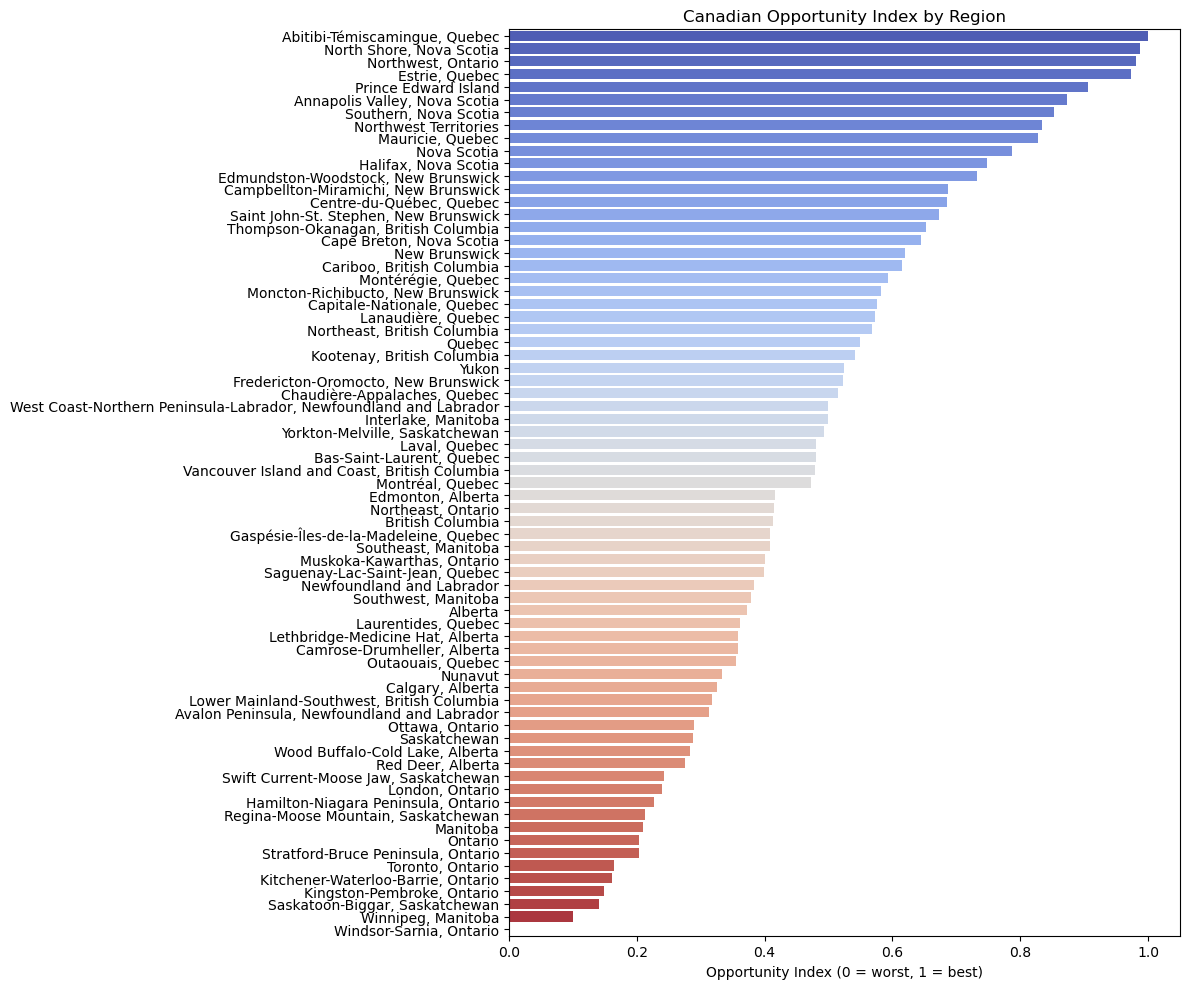

In [74]:
plt.figure(figsize=(12, 10))
sns.barplot(
    data=merged[merged['Geography'] != 'Canada'],  # exclude Canada row
    x='Canadian_Opportunity_Index',
    y='Geography', hue="Geography",
    legend=False,palette='coolwarm'
)
plt.title('Canadian Opportunity Index by Region', fontsize=12)
plt.xlabel('Opportunity Index (0 = worst, 1 = best)')
plt.ylabel('')
plt.tight_layout()

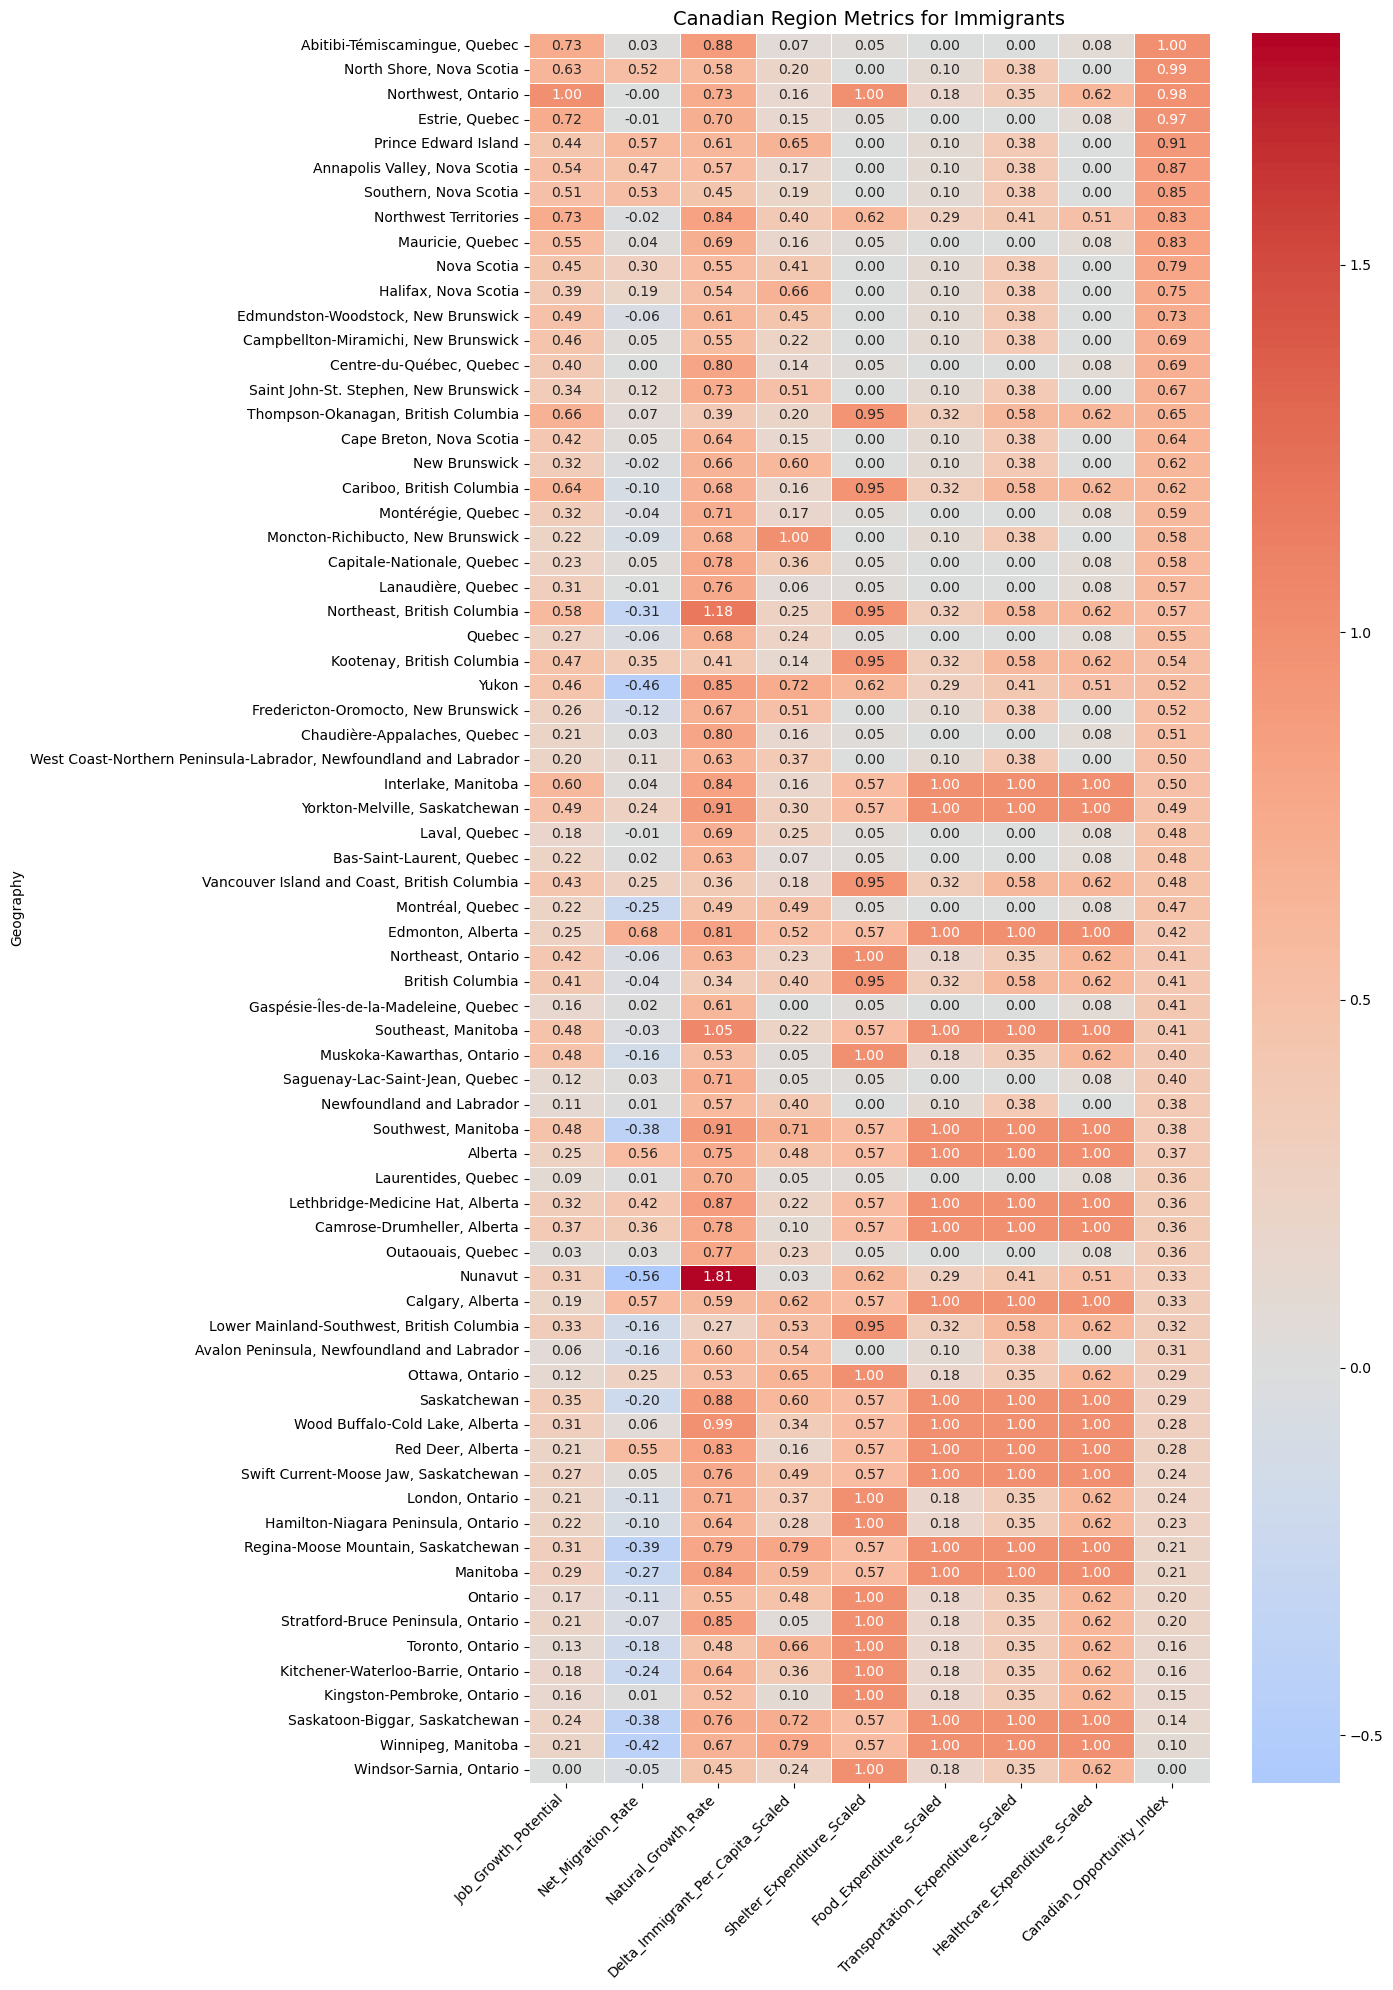

In [75]:
heatmap_cols = [
    'Job_Growth_Potential',
    'Net_Migration_Rate', 
    'Natural_Growth_Rate',
    'Delta_Immigrant_Per_Capita_Scaled',
    'Shelter_Expenditure_Scaled',
    'Food_Expenditure_Scaled',
    'Transportation_Expenditure_Scaled',
    'Healthcare_Expenditure_Scaled',
    'Canadian_Opportunity_Index'
]

heatmap_data = merged[merged['Geography'] != 'Canada'].set_index('Geography')[heatmap_cols]

plt.figure(figsize=(14, 20))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar=True
)
plt.title('Canadian Region Metrics for Immigrants', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [76]:
merged.to_csv('canadian_immigration.csv', index=False)